# 📈 03 — Evaluación, Optimización y Análisis No Supervisado

## ¿Qué respondemos en este notebook?

Este notebook profundiza en tres preguntas adicionales de negocio:

---

### ❓ Pregunta 3 — Optimización de Hiperparámetros
> **¿Podemos mejorar la predicción de segmento de desempeño ajustando los parámetros del modelo?**
>
> *¿Por qué importa?* Un modelo bien afinado reduce los falsos negativos: empleados clasificados
> como 'Medio' que en realidad están en 'Bajo' y necesitan intervención urgente.
> Cada error de clasificación tiene un costo real para la empresa.

---

### ❓ Pregunta 4 — Clustering (No Supervisado)
> **¿Existen grupos naturales de empleados con perfiles similares que no coincidan con los segmentos de desempeño?**
>
> *¿Por qué importa?* El clustering permite descubrir perfiles ocultos: por ejemplo,
> un grupo de empleados con alta antigüedad, bajo salario y muchas ausencias puede ser
> un grupo de riesgo de renuncia que no se detecta solo mirando el desempeño.

---

### ❓ Pregunta 5 — Comparación Final
> **¿Cuál es el mejor modelo para producción y qué tan confiable es?**
>
> *¿Por qué importa?* RR.HH. necesita saber en qué modelo confiar al momento de tomar
> decisiones de personal. La comparación rigurosa con validación cruzada garantiza
> que el modelo elegido no está sobreajustado a los datos de entrenamiento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, silhouette_score, classification_report

sns.set_theme(style='whitegrid')
RUTA = Path('../data/03_primary/rrhh_encoded.csv')
RANDOM_STATE = 42

## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv(RUTA, encoding='cp1252')

EXCLUIR = [c for c in ['segmento_desempeno', 'score_desempeno', 'riesgo_ausentismo',
                        'nombre', 'rut', 'fecha_ingreso'] if c in df.columns]
X_raw = df.drop(columns=EXCLUIR).select_dtypes(include=[np.number])
y     = df['segmento_desempeno']

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'NaN en X: {X.isna().sum().sum()}')

Train: (228, 51) | Test: (58, 51)
NaN en X: 0


## 2. Optimización con GridSearchCV — RandomForest

**¿Por qué GridSearchCV?**
Prueba exhaustivamente todas las combinaciones de hiperparámetros con validación cruzada.
Ideal para RandomForest porque el espacio de búsqueda es manejable.
Maximizamos **F1 ponderado** porque las clases están desbalanceadas (pocos empleados 'Alto').

In [3]:
param_grid_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight':     ['balanced'],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

print(f'\n✅ Mejor F1 (CV): {grid_rf.best_score_:.4f}')
print(f'Mejores parámetros RF: {grid_rf.best_params_}')

pred_grid = grid_rf.best_estimator_.predict(X_test)
print(f'\nF1 en test (RF optimizado): {f1_score(y_test, pred_grid, average="weighted", zero_division=0):.4f}')
print(classification_report(y_test, pred_grid, zero_division=0))

Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Mejor F1 (CV): 0.8952
Mejores parámetros RF: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}

F1 en test (RF optimizado): 0.9150
              precision    recall  f1-score   support

        Alto       0.00      0.00      0.00         2
        Bajo       1.00      0.91      0.95        23
       Medio       0.89      1.00      0.94        33

    accuracy                           0.93        58
   macro avg       0.63      0.64      0.63        58
weighted avg       0.90      0.93      0.91        58



## 3. Optimización con RandomizedSearchCV — GradientBoosting

**¿Por qué RandomizedSearchCV para GBM?**
GradientBoosting tiene un espacio de hiperparámetros muy grande. Buscar exhaustivamente
tomaría horas. RandomizedSearchCV muestrea aleatoriamente combinaciones y encuentra
soluciones muy buenas en fracción del tiempo.

In [4]:
param_dist_gbm = {
    'n_estimators':      [50, 100, 150, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [3, 4, 5, 6, 8],
    'subsample':         [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
}

rnd_gbm = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_dist_gbm, n_iter=30, cv=5,
    scoring='f1_weighted', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rnd_gbm.fit(X_train, y_train)

print(f'\n✅ Mejor F1 (CV): {rnd_gbm.best_score_:.4f}')
print(f'Mejores parámetros GBM: {rnd_gbm.best_params_}')

pred_rnd = rnd_gbm.best_estimator_.predict(X_test)
print(f'\nF1 en test (GBM optimizado): {f1_score(y_test, pred_rnd, average="weighted", zero_division=0):.4f}')
print(classification_report(y_test, pred_rnd, zero_division=0))

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Mejor F1 (CV): 0.8941
Mejores parámetros GBM: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.05}

F1 en test (GBM optimizado): 0.9800
              precision    recall  f1-score   support

        Alto       1.00      0.50      0.67         2
        Bajo       1.00      1.00      1.00        23
       Medio       0.97      1.00      0.99        33

    accuracy                           0.98        58
   macro avg       0.99      0.83      0.88        58
weighted avg       0.98      0.98      0.98        58



### Comparación modelos optimizados vs. base

[05/25/26 19:15:19] WARNING  C:\Users\nholc\AppData\Local\Temp\ipykernel_24980\3330671458.py:12:    warnings.py:112
                             FutureWarning:                                                                        
                                                                                                                   
                             Passing `palette` without assigning `hue` is deprecated and will be                   
                             removed in v0.14.0. Assign the `x` variable to `hue` and set                          
                             `legend=False` for the same effect.                                                   
                                                                                                                   
                               bars = sns.barplot(data=resumen_opt, x='modelo', y='f1_weighted',                   
                             palette='viridis')                                                                    
                                                                                                                   

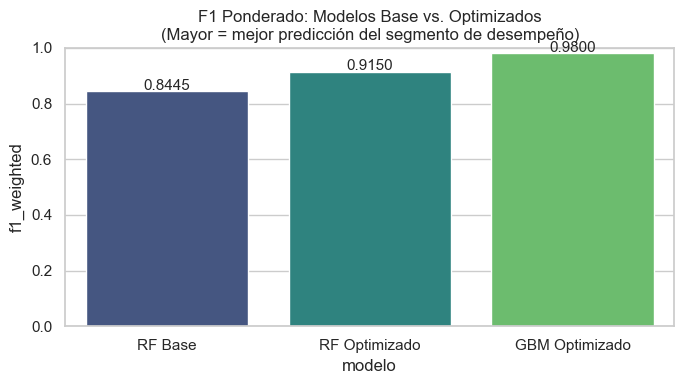

        modelo  f1_weighted
       RF Base       0.8445
 RF Optimizado       0.9150
GBM Optimizado       0.9800


In [5]:
# Modelo base para comparar
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
rf_base.fit(X_train, y_train)

resumen_opt = pd.DataFrame([
    {'modelo': 'RF Base',        'f1_weighted': round(f1_score(y_test, rf_base.predict(X_test),  average='weighted', zero_division=0), 4)},
    {'modelo': 'RF Optimizado',  'f1_weighted': round(f1_score(y_test, pred_grid, average='weighted', zero_division=0), 4)},
    {'modelo': 'GBM Optimizado', 'f1_weighted': round(f1_score(y_test, pred_rnd,  average='weighted', zero_division=0), 4)},
])

plt.figure(figsize=(7, 4))
bars = sns.barplot(data=resumen_opt, x='modelo', y='f1_weighted', palette='viridis')
for i, v in enumerate(resumen_opt['f1_weighted']):
    bars.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=11)
plt.title('F1 Ponderado: Modelos Base vs. Optimizados\n(Mayor = mejor predicción del segmento de desempeño)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(resumen_opt.to_string(index=False))

## 4. Clustering con KMeans — Perfiles Ocultos de Empleados

### 🎯 ¿Qué estamos buscando y para qué?

**Objetivo:** Descubrir si existen grupos naturales de empleados más allá de los segmentos
de desempeño. Un cluster podría revelar, por ejemplo:
- Empleados con **alta antigüedad + bajo salario + muchas ausencias** → riesgo de renuncia.
- Empleados con **contrato a plazo fijo + pocas capacitaciones** → baja motivación.
- Empleados con **jornada parcial + muchas licencias** → perfil de salud vulnerable.

Estos patrones son **invisibles** si solo miramos el desempeño.
El clustering es aprendizaje **no supervisado**: no le decimos al algoritmo qué buscar,
él encuentra la estructura por sí solo.

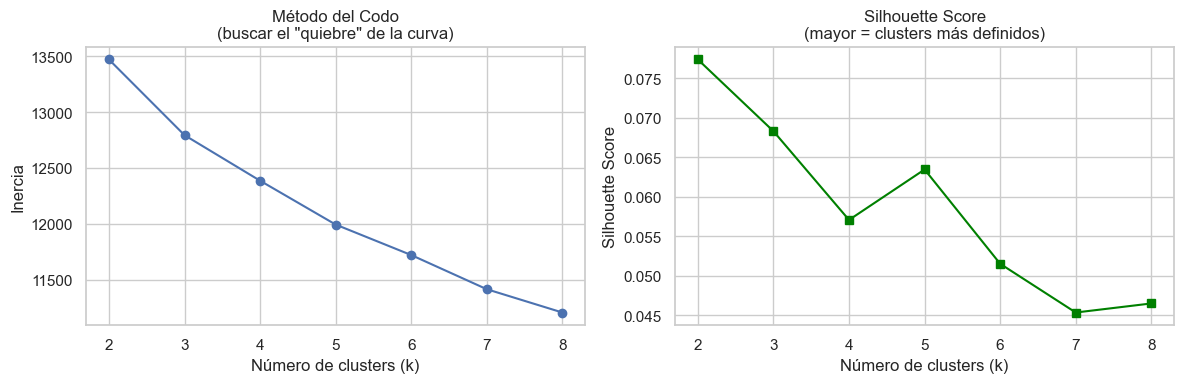


📌 k óptimo según Silhouette: 2
 k      inertia  silhouette
 2 13469.727679    0.077371
 3 12793.309696    0.068293
 4 12386.125728    0.057070
 5 11994.259453    0.063453
 6 11721.750539    0.051519
 7 11416.279609    0.045353
 8 11208.112022    0.046501


In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

resultados_codo = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    resultados_codo.append({
        'k': k,
        'inertia':   km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels)
    })

codo = pd.DataFrame(resultados_codo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(codo['k'], codo['inertia'], marker='o')
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo\n(buscar el "quiebre" de la curva)')

ax2.plot(codo['k'], codo['silhouette'], marker='s', color='green')
ax2.set_xlabel('Número de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score\n(mayor = clusters más definidos)')

plt.tight_layout()
plt.show()

k_optimo = int(codo.loc[codo['silhouette'].idxmax(), 'k'])
print(f'\n📌 k óptimo según Silhouette: {k_optimo}')
print(codo.to_string(index=False))

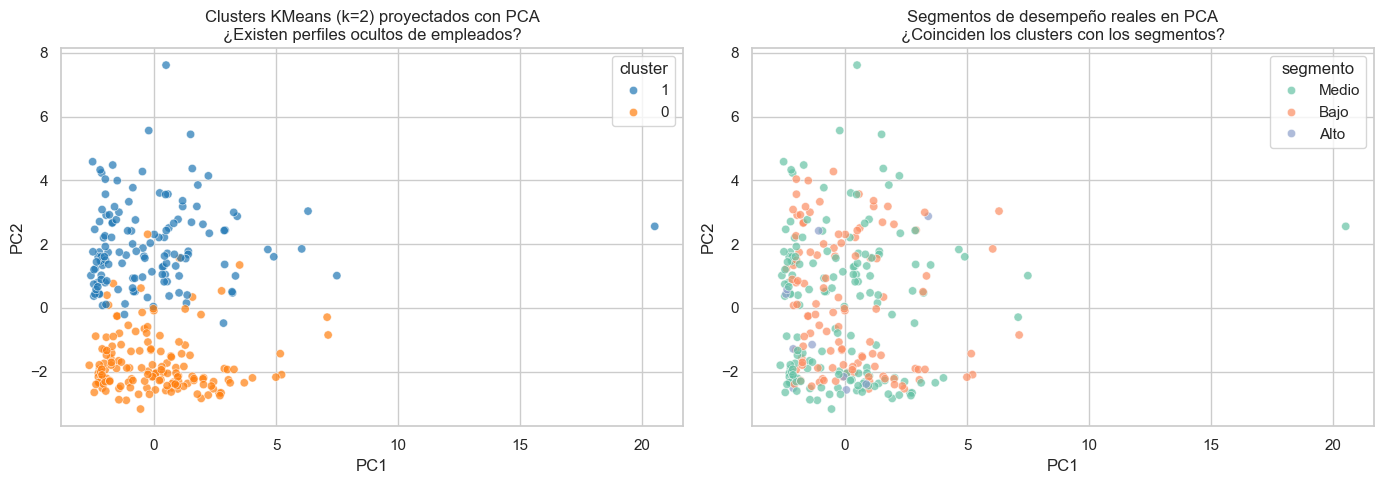

Varianza explicada por PC1+PC2: 19.9%


In [7]:
km_final = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=10)
clusters = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    'PC1':     X_pca[:, 0],
    'PC2':     X_pca[:, 1],
    'cluster': clusters.astype(str),
    'segmento': y.values
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='cluster',
                palette='tab10', ax=ax1, alpha=0.7)
ax1.set_title(f'Clusters KMeans (k={k_optimo}) proyectados con PCA\n'
              '¿Existen perfiles ocultos de empleados?')

sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='segmento',
                palette='Set2', ax=ax2, alpha=0.7)
ax2.set_title('Segmentos de desempeño reales en PCA\n'
              '¿Coinciden los clusters con los segmentos?')

plt.tight_layout()
plt.show()

varianza = pca.explained_variance_ratio_.sum()
print(f'Varianza explicada por PC1+PC2: {varianza:.1%}')

In [8]:
# Perfil de cada cluster: medias de las variables más importantes
X_clusters = X.copy()
X_clusters['cluster'] = clusters
X_clusters['segmento'] = y.values

print('📊 Perfil promedio por cluster:')
perfil = X_clusters.groupby('cluster').mean(numeric_only=True).round(2)
print(perfil.T.head(15).to_string())

print('\n📊 Distribución de segmentos dentro de cada cluster:')
print(pd.crosstab(X_clusters['cluster'], X_clusters['segmento']))

📊 Perfil promedio por cluster:
cluster                               0           1
id_empleado                      156.92      139.97
salario                      2836479.89  2746841.33
antiguedad_anios                   6.50        6.95
total_ausencias                    1.13        1.06
dias_ausencia_total               16.82       16.71
dias_ausencia_promedio            14.70       15.37
ausencias_injustificadas           0.21        0.20
dias_ausencia_just_no              2.71        2.72
dias_ausencia_just_sã­            18.45       19.43
total_capacitaciones               0.64        1.89
horas_capacitacion_total          25.79       70.15
horas_capacitacion_promedio       38.84       38.22
nota_promedio_capacitacion         4.00        4.05
capacitaciones_completadas         0.00        1.32
cumple_min_capacitaciones          0.00        1.00

📊 Distribución de segmentos dentro de cada cluster:
segmento  Alto  Bajo  Medio
cluster                    
0            6    64     82


## 5. Resumen Final y Recomendaciones

### Respuestas a las preguntas de negocio

| Pregunta de Negocio | Técnica | Resultado |
|---|---|---|
| ¿En qué segmento está el empleado? | Clasificación supervisada | Ver `resumen_opt` |
| ¿Cuál será su puntaje exacto? | Regresión supervisada | Ver notebook 02 |
| ¿Podemos mejorar la predicción? | GridSearchCV / RandomizedSearchCV | Ver `resumen_opt` |
| ¿Existen perfiles ocultos? | KMeans + PCA | Ver gráfico de clusters |

### Recomendaciones de Producción

1. **Modelo elegido para clasificación:** El que obtuvo mayor F1 en `resumen_opt`.
   Usar sus `best_params_` en el pipeline de Kedro.

2. **Monitoreo de clusters:** Revisar trimestralmente si el cluster de mayor riesgo
   (menor segmento promedio + mayor ausentismo) ha crecido.

3. **Actualización del modelo:** Re-entrenar cada 6 meses con datos nuevos para
   capturar cambios en la composición de la fuerza laboral.

4. **Limitación:** El dataset es pequeño (286 empleados). Los resultados deben
   interpretarse con cautela y validarse con el equipo de RR.HH. antes de usarlos
   para decisiones de personal.

In [9]:
resumen_final = {
    'mejor_modelo_clasificacion': resumen_opt.sort_values('f1_weighted', ascending=False).iloc[0]['modelo'],
    'mejor_f1':                   resumen_opt['f1_weighted'].max(),
    'k_clusters':                 k_optimo,
    'mejor_silhouette':           codo['silhouette'].max(),
    'varianza_pca_2d':            round(varianza, 4),
}
pd.Series(resumen_final)


mejor_modelo_clasificacion    GBM Optimizado
mejor_f1                                0.98
k_clusters                                 2
mejor_silhouette                    0.077371
varianza_pca_2d                       0.1988
dtype: object